# **literature  review**

The **Pima Indians Diabetes Dataset** is one of the most widely used benchmark datasets for binary classification in healthcare and was originally collected by the **National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK)**. It contains medical records of **768 female patients aged 21 years or older of Pima Indian heritage**, with the objective of predicting diabetes using eight clinical measurements. Previous studies and highly-rated Kaggle notebooks consistently identify **Glucose** as the strongest predictor of diabetes, followed by **BMI**, **Insulin**, **Age**, and **Diabetes Pedigree Function**. A common preprocessing step recommended across the literature is treating biologically impossible **zero values** in Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI as missing values before imputation. The dataset is also known for its moderate class imbalance (500 non-diabetic vs. 268 diabetic cases) and is widely used to compare machine learning algorithms such as Logistic Regression, Random Forest, Support Vector Machine, XGBoost, and Neural Networks. Overall, it remains a standard benchmark for evaluating preprocessing techniques, feature engineering, and diabetes prediction models. :contentReference[oaicite:0]{index=0}

### References

1. **Kaggle Dataset (Official)**
   - :contentReference[oaicite:1]{index=1}

2. **Original Research Paper**
   - Smith, J. W., Everhart, J. E., Dickson, W. C., Knowler, W. C., & Johannes, R. S. (1988). *Using the ADAP Learning Algorithm to Forecast the Onset of Diabetes Mellitus.* (Referenced in the Kaggle dataset page.) :contentReference[oaicite:2]{index=2}

3. **Systematic Literature Review**
   - :contentReference[oaicite:3]{index=3}

4. **Research Using the Pima Dataset**
   - :contentReference[oaicite:4]{index=4}

| Feature(s)                                                  | The Specific Anomaly/Pitfall (e.g., 0 values)                       | What the Literature/Top Notebooks Recommend (Imputation vs. Dropping)                                                                                            | Impact on Analysis if Ignored                                                                                                                                                    |
| ----------------------------------------------------------- | ------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Glucose                                                     | 5 rows with value = 0 (impossible for living adults).               | Treat 0 as missing (NaN) and impute (median or regression-based); some studies drop rows with multiple implausible zeros arslaankola.github+2.                   | Artificially lowers mean glucose, distorts correlations with Outcome, and biases any model using raw values arslaankola.github.                                                  |
| BloodPressure                                               | 35 rows with value = 0 (impossible diastolic pressure).             | Convert 0 to missing and impute (median or model-based); some pipelines drop rows with multiple zeros arslaankola.github+2.                                      | Biases mean and variance of blood pressure; can create spurious weak relationships or mask real associations with Outcome arslaankola.github.                                    |
| SkinThickness                                               | 227 rows with value = 0 (implausible for adult skinfold).           | Treat 0 as missing and impute (median preferred due to outliers); many analyses keep rows but fix missing values arslaankola.github+2.                           | Strongly distorts distribution; inflates zero-heavy mode and weakens correlation with diabetes risk; can mislead feature importance arslaankola.github.                          |
| Insulin                                                     | 374 rows with value = 0 (biologically impossible).                  | Convert 0 to missing; impute using median or regression on other features (e.g., Glucose, Age); some studies drop rows with multiple zeros arslaankola.github+2. | Severely biases mean insulin upward (if zeros counted as real) or downward (if treated as 0), corrupts correlations, and reduces predictive power of insulin arslaankola.github. |
| BMI                                                         | 11 rows with value = 0 (impossible body mass index).                | Treat 0 as missing and impute (median or regression-based); some analyses drop rows with multiple implausible zeros arslaankola.github+2.                        | Artificially lowers mean BMI, distorts BMI–Outcome relationship, and can misclassify obese individuals as “normal” or “missing” arslaankola.github.                              |
| All 5 (Glucose, BloodPressure, SkinThickness, Insulin, BMI) | Zeros in multiple columns simultaneously (e.g., 0 BMI + 0 glucose). | Flag as potentially corrupted; some pipelines drop such rows, others apply multi-variable imputation or regression arslaankola.github+2.                         | May represent severely poor recording; if kept as 0, they can dominate model behavior and create unrealistic patterns in EDA and modeling arslaankola.github.                    |
| Outcome (class variable)                                    | Mild class imbalance: ~34.9% diabetic vs. 65.1% non-diabetic.       | Use stratified cross-validation; consider class weighting or recall/F1-focused optimization rather than raw accuracy alone medrxiv+1.                            | Models may overfit to the majority class, yielding high accuracy but poor sensitivity for diabetic patients medrxiv+1.                                                           |

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 

In [7]:
df=pd.read_csv("diabetes.csv")
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
556,1,97,70,40,0,38.1,0.218,30,0
562,1,87,68,34,77,37.6,0.401,24,0
316,3,99,80,11,64,19.3,0.284,30,0
174,2,75,64,24,55,29.7,0.370,33,0
282,7,133,88,15,155,32.4,0.262,37,0
341,1,95,74,21,73,25.9,0.673,36,0
302,5,77,82,41,42,35.8,0.156,35,0
285,7,136,74,26,135,26.0,0.647,51,0
207,5,162,104,0,0,37.7,0.151,52,1
380,1,107,72,30,82,30.8,0.821,24,0


### Feature explaination 

| Variable Name            | Clinical Meaning/Definition                                               | Standard Medical Range (Healthy vs. Diabetic)                                                                               | Why it Matters for Diabetes Risk                                                                                                                                                                        |
| ------------------------ | ------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Pregnancies              | Number of times the woman has been pregnant.                              | No strict “healthy” range; higher parity often associated with increased risk, especially if gestational diabetes occurred. | Higher parity can reflect cumulative metabolic stress and history of gestational diabetes, both linked to later type 2 diabetes risk arslaankola.github+2.                                              |
| Glucose                  | Plasma glucose concentration (mg/dL), typically 2-hour post–glucose load. | Healthy: <140 mg/dL (post-load); Diabetic: ≥200 mg/dL (post-load) per WHO/ADA criteria.                                     | Glucose is the core diagnostic criterion for diabetes; highest correlation with Outcome and strongest predictor in logistic and ML models arslaankola.github+3.                                         |
| BloodPressure            | Diastolic blood pressure (mmHg).                                          | Healthy: <80 mmHg; Elevated: ≥80–90 mmHg; Diabetic/hypertensive risk: ≥90 mmHg.                                             | Hypertension is part of metabolic syndrome and associated with insulin resistance; however, in this dataset its predictive power is weaker than glucose/BMI arslaankola.github+1.                       |
| SkinThickness            | Triceps skinfold thickness (mm), surrogate for subcutaneous fat.          | No strict diagnostic cutoff; higher values generally indicate greater adiposity.                                            | Reflects overall body fat and insulin resistance, but often noisy and less predictive than BMI; many 0 values indicate missing data arslaankola.github+2.                                               |
| Insulin                  | 2-hour serum insulin (µU/mL), reflecting compensatory insulin secretion.  | No universal diagnostic range; high levels suggest hyperinsulinemia/insulin resistance.                                     | Hyperinsulinemia indicates early dysmetabolism, but measurement is noisy and has many implausible zeros; often not a strong independent predictor after adjusting for glucose/BMI arslaankola.github+1. |
| BMI                      | Body Mass Index (kg/m²), measure of overall adiposity.                    | Healthy: 18.5–24.9; Overweight: 25–29.9; Obese: ≥30.                                                                        | Obesity is a major driver of type 2 diabetes via insulin resistance and inflammation; BMI is consistently one of the top predictors alongside glucose arslaankola.github+3.                             |
| DiabetesPedigreeFunction | Weighted score of family history of diabetes in relatives.                | No fixed range; higher values indicate stronger family history.                                                             | Captures genetic predisposition and shared environmental risk; in logistic models, higher scores significantly increase diabetes risk independently of current metabolic measures arslaankola.github+3. |
| Age                      | Age of the woman (years).                                                 | No diagnostic cutoff; risk increases with age.                                                                              | Older age is associated with cumulative metabolic stress, declining beta‑cell function, and higher adiposity; consistently a significant predictor in Pima studies arslaankola.github+2.                |

In [8]:
df.shape

(768, 9)

## Data Cleaning:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [11]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


##  imputation

Reason for Linear Regression Imputation
Zeros in Glucose, BloodPressure, SkinThickness, Insulin, and BMI are biologically impossible; they are missing values, not real data.

Treating them as 0 distorts means, variances, and correlations, leading to biased models.

Linear regression uses relationships between features (e.g., Glucose with Age, BMI) to predict realistic values.

This method provided the best overall improvement across models on the Pima dataset in prior studies.

It preserves data distribution better than simple mean/median replacement while remaining interpretable.

In [18]:

# 2. Columns with illegal zeros
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 3. Convert zeros to NaN (treat as missing)
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)

# 4. Define feature columns (excluding Outcome)
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# 5. Linear Regression imputation function (fixed version)
def lr_impute(df, target_col, predictor_cols):
    mask_missing = df[target_col].isna()
    mask_valid = ~mask_missing

    if mask_missing.sum() == 0:
        return df  # nothing to impute

    # Use only rows where target AND all predictors are NOT missing
    mask_both = mask_valid & df[predictor_cols].notna().all(axis=1)

    if mask_both.sum() < 2:
        # Too few valid rows to fit regression; fallback to median
        median_val = df[target_col].median()
        df.loc[mask_missing, target_col] = median_val
        return df

    X_train = df.loc[mask_both, predictor_cols].values
    y_train = df.loc[mask_both, target_col].values

    model = LinearRegression()
    model.fit(X_train, y_train)

    # For missing rows, use only predictors that are non-missing
    mask_missing_for_pred = mask_missing & df[predictor_cols].notna().all(axis=1)
    if mask_missing_for_pred.sum() > 0:
        X_missing = df.loc[mask_missing_for_pred, predictor_cols].values
        y_pred = model.predict(X_missing)
        df.loc[mask_missing_for_pred, target_col] = y_pred

    # Any rows where predictors still have NaN -> fallback to median
    remaining_missing = mask_missing & ~mask_missing_for_pred
    if remaining_missing.sum() > 0:
        median_val = df.loc[mask_valid, target_col].median()
        df.loc[remaining_missing, target_col] = median_val

    return df
# 6. Impute in order; for each, use other features as predictors
for col in cols_with_zeros:
    predictors = [c for c in feature_cols if c != col]
    df = lr_impute(df, col, predictors)

# 7. Now df should have no NaN in these columns
print(df[cols_with_zeros].isna().sum())

# 8. Optional: check correlations
corr = df[feature_cols].corr()
print("Correlation matrix (after imputation):")
print(corr.round(2))

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
Correlation matrix (after imputation):
                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                      1.00     0.13           0.21           0.08   
Glucose                          0.13     1.00           0.22           0.19   
BloodPressure                    0.21     0.22           1.00           0.19   
SkinThickness                    0.08     0.19           0.19           1.00   
Insulin                          0.04     0.70           0.13           0.20   
BMI                              0.02     0.23           0.28           0.54   
DiabetesPedigreeFunction        -0.03     0.14          -0.00           0.10   
Age                              0.54     0.27           0.32           0.13   

                          Insulin   BMI  DiabetesPedigreeFunction   Age  
Pregnancies                  0.04  0.02                   

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.630770,30.450376,44.000000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,152.099639,97.776089,21.862645,88.44139,130.0000,190.00000,846.00
BMI,768.0,32.452551,6.875865,18.200000,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078000,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000000,0.00000,0.0000,1.00000,1.00


In [23]:
df["Insulin"] = df["Insulin"].clip(lower=df["Insulin"].quantile(0.01))

Linear Regression imputation can predict unrealistic (even negative) insulin values. Clipping replaces extremely low predicted values with the 1st percentile, ensuring biologically plausible insulin levels without significantly altering the overall distribution.

## Univariate Analysis:

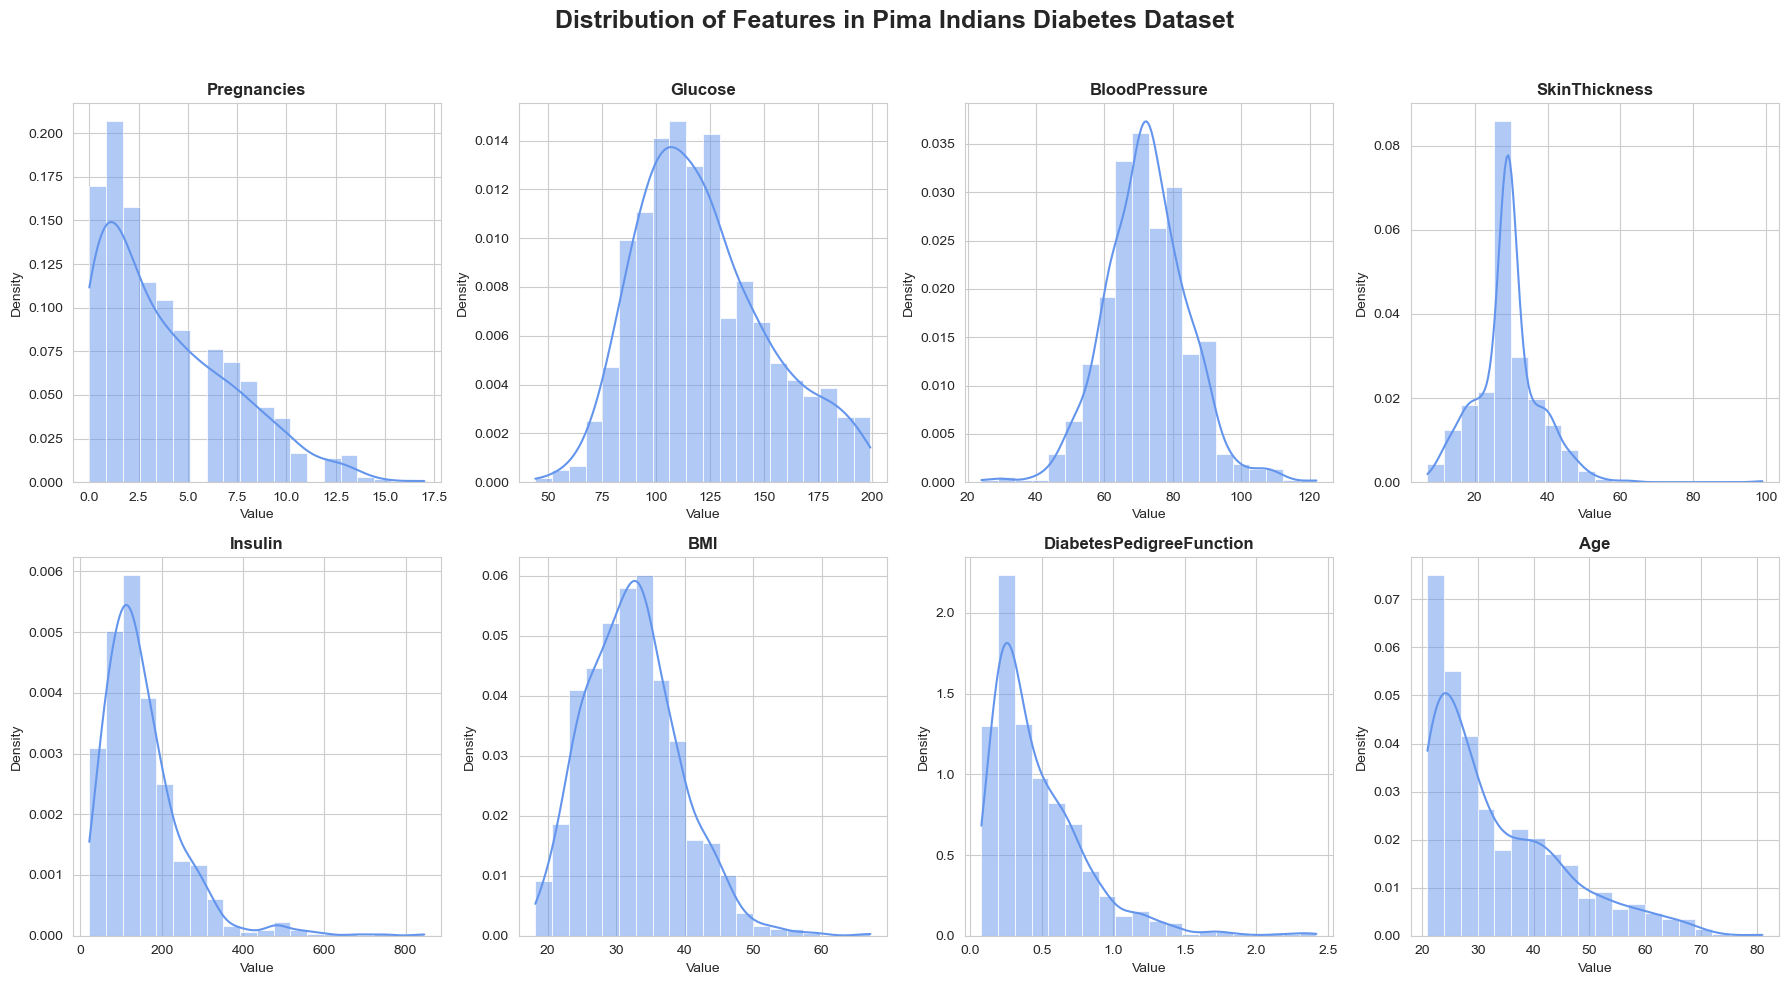

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features (excluding target)
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age']

# Style
sns.set_style("whitegrid")

# Create figure
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        bins=20,
        kde=True,
        stat='density',
        color='cornflowerblue',
        edgecolor='white',
        linewidth=0.5,
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")

# Overall Title
plt.suptitle(
    "Distribution of Features in Pima Indians Diabetes Dataset",
    fontsize=18,
    fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Pregnancies: Right-skewed

Glucose: Slightly right-skewed

BloodPressure: Approximately normal

SkinThickness: Right-skewed

Insulin: Highly right-skewed with extreme outliers

BMI: Slightly right-skewed

DiabetesPedigreeFunction: Highly right-skewed

Age: Right-skewed

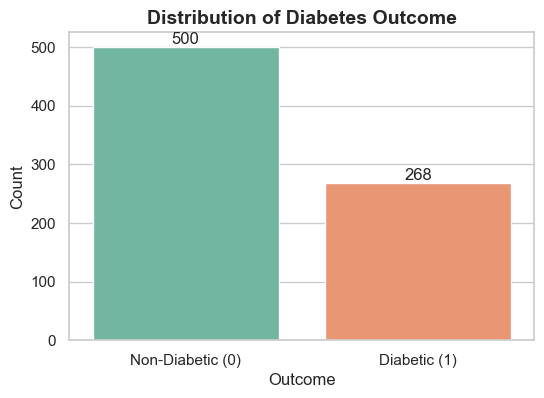

In [59]:
plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=df,
    x='Outcome',hue='Outcome',legend=False,
    palette='Set2')
plt.title("Distribution of Diabetes Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks([0,1], ["Non-Diabetic (0)", "Diabetic (1)"])
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Bivariate Analysis:

## Pregnancies vs Outcome

In [60]:
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age']

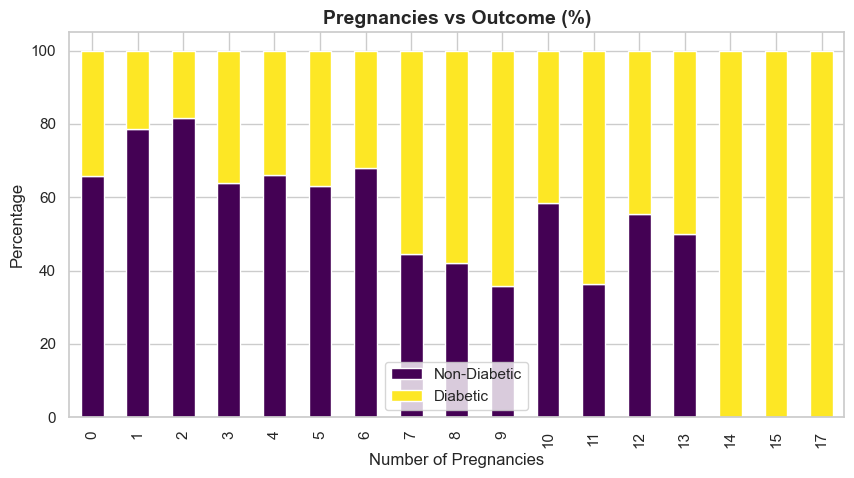

In [97]:
preg = pd.crosstab(df['Pregnancies'], df['Outcome'], normalize='index') * 100
preg.plot(
    kind='bar',stacked=True,figsize=(10,5),colormap='viridis')
plt.title('Pregnancies vs Outcome (%)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Pregnancies')
plt.ylabel('Percentage')
plt.legend(['Non-Diabetic','Diabetic'])

plt.show()

- Individuals with 0–6 pregnancies are predominantly non-diabetic, with the non-diabetic group making up the majority in most categories.
- From approximately 7 pregnancies onward, the proportion of diabetic individuals generally increases, and for several higher pregnancy counts (e.g., 9, 11, 14, 15, and 17), diabetic individuals constitute the majority.
- Although an increasing trend in diabetes prevalence is visible with higher pregnancy counts, the bars for very high pregnancy numbers likely represent fewer observations and should be interpreted cautiously.

* **Conclusion:** : The visual suggests that a higher number of pregnancies is associated with an increased proportion of diabetes, indicating that pregnancy history may be an important predictor of diabetes risk.

## Glucose Distribution by Diabetes Outcome

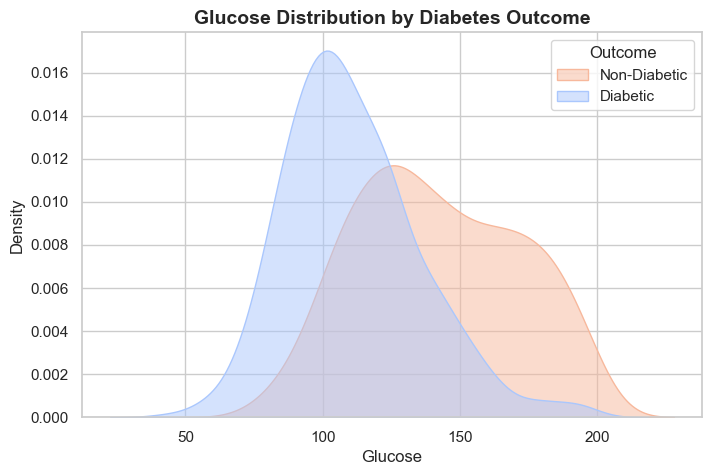

In [70]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x='Glucose',
    hue='Outcome',
    fill=True,
    common_norm=False,
    palette='coolwarm',
    alpha=0.5)
plt.title('Glucose Distribution by Diabetes Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Glucose')
plt.ylabel('Density')
plt.legend(title='Outcome', labels=['Non-Diabetic', 'Diabetic'])
plt.show()

- The glucose distribution for diabetic individuals is shifted toward higher glucose values compared to the non-diabetic group, indicating generally elevated glucose levels.
- While there is some overlap between the two distributions, the separation becomes more apparent at higher glucose levels, where diabetic individuals are much more prevalent.
- Glucose provides one of the clearest distinctions between the two outcome groups, with non-diabetic individuals concentrated at lower glucose levels and diabetic individuals more frequently exhibiting elevated glucose values.

* **Conclusion:** Glucose shows a strong positive association with diabetes, making it one of the most influential features for distinguishing diabetic from non-diabetic individuals.

### Blood Pressure vs Outcome

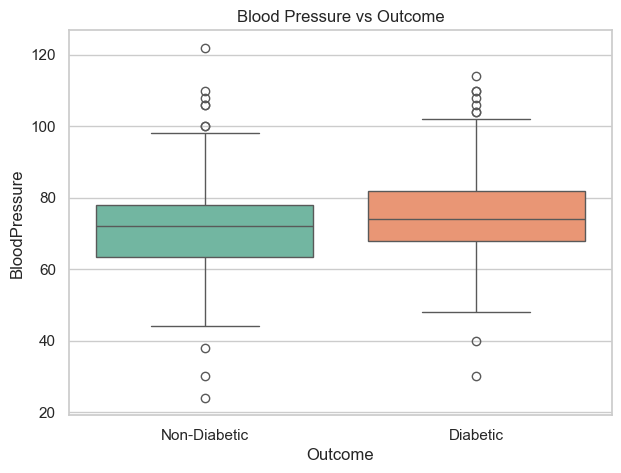

In [96]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x='Outcome', y='BloodPressure',hue='Outcome',legend=False,palette='Set2')
plt.title('Blood Pressure vs Outcome')
plt.xticks([0,1],['Non-Diabetic','Diabetic'])
plt.show()

- The diabetic group has a slightly higher median blood pressure than the non-diabetic group.
- The two boxes overlap considerably, showing that blood pressure values are fairly similar across both groups.
- Both groups contain a few unusually high and low blood pressure values, indicating the presence of outliers.

* **Conclusion:** Blood pressure tends to be slightly higher among diabetic individuals, but the strong overlap suggests it is a relatively weak standalone indicator of diabetes.

## Skin Thickness by Outcome

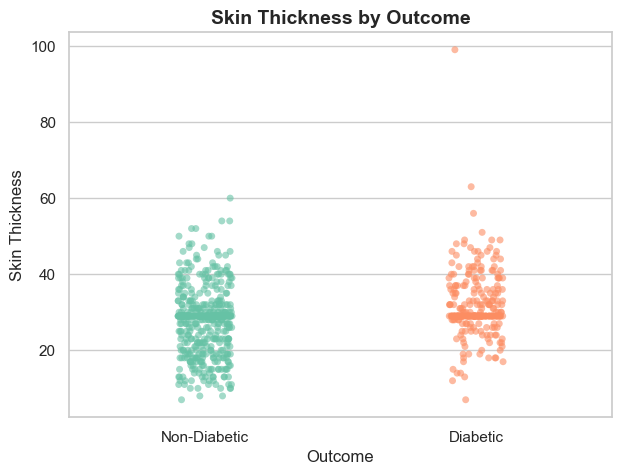

In [94]:
plt.figure(figsize=(7,5))

sns.stripplot(
    data=df,
    x='Outcome',
    y='SkinThickness',
    palette='Set2',
    hue='Outcome',legend=False,

    jitter=True,
    alpha=0.6)
plt.title('Skin Thickness by Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Outcome')
plt.ylabel('Skin Thickness')
plt.xticks([0,1], ['Non-Diabetic','Diabetic'])

plt.show()

- Most observations in both groups fall between roughly 20 and 40 mm, creating a noticeable overlap.
- The diabetic group shows a slightly wider spread and includes a few much higher skin thickness values than the non-diabetic group.
- Since the points from both groups are heavily mixed together, skin thickness alone does not clearly separate diabetic from non-diabetic individuals.

* **Conclusion:** Skin thickness shows only a modest relationship with diabetes, as both groups share a very similar overall distribution despite a few higher values in the diabetic group.

## BMI by Diabetes Outcome

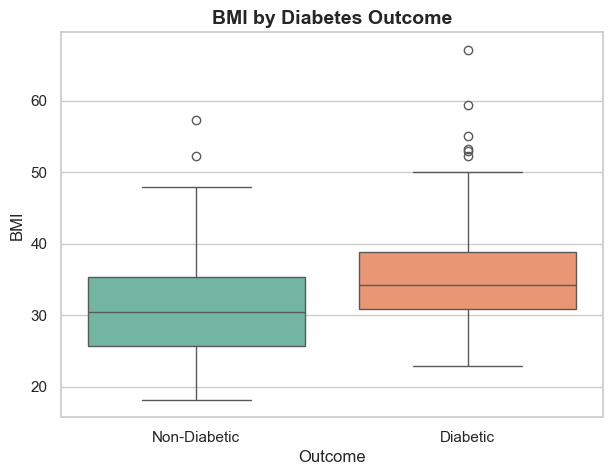

In [93]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,x='Outcome',hue='Outcome',legend=False,y='BMI',palette='Set2')
plt.title('BMI by Diabetes Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Outcome')
plt.ylabel('BMI')
plt.xticks([0,1], ['Non-Diabetic','Diabetic'])
plt.show()

- The diabetic group has a noticeably higher median BMI than the non-diabetic group.
- BMI values are generally more spread out among diabetic individuals, with several high-value outliers.
- Although the two groups overlap, the diabetic group is shifted toward higher BMI values, suggesting a stronger association with diabetes.

* **Conclusion:** Individuals with diabetes generally have higher BMI values, making BMI one of the more informative features associated with diabetes risk.

##  Distribution of Insulin by Diabetes Outcome

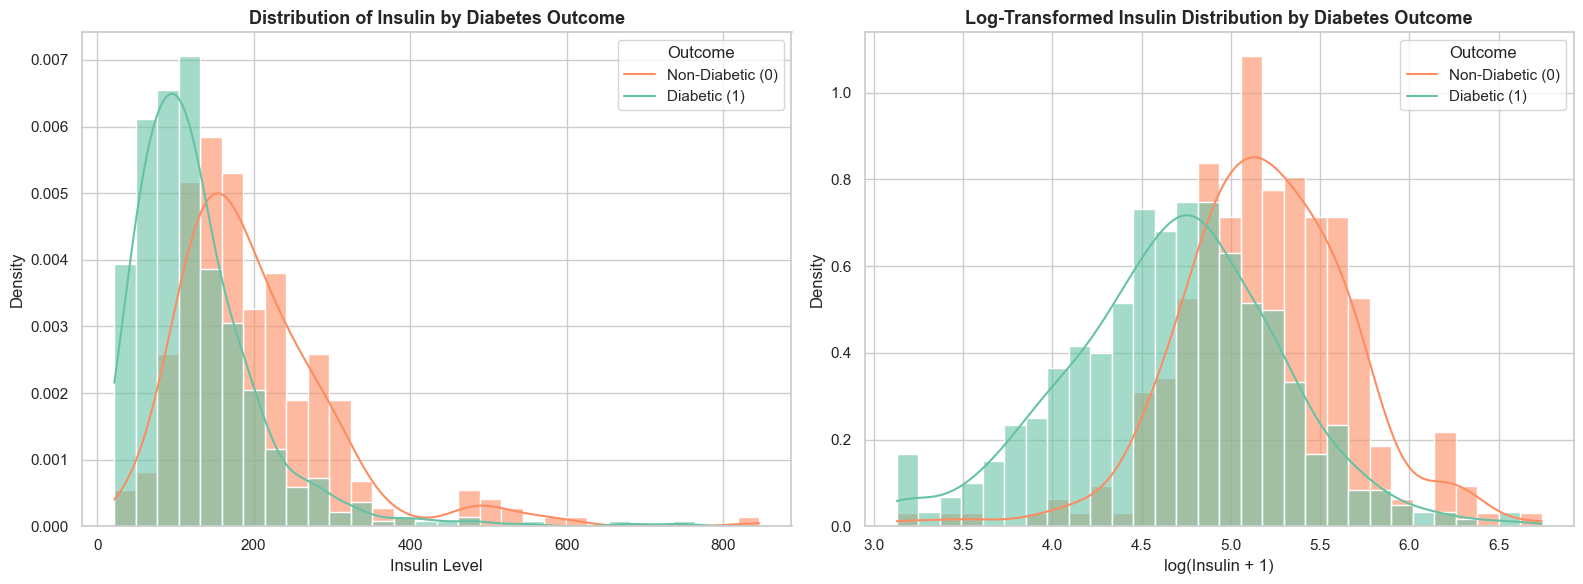

In [92]:
# 1. Create the log-transformed column first
df['Log_Insulin'] = np.log1p(df['Insulin'])

# 2. Create a single canvas with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# --- Left Plot: Original Insulin ---
sns.histplot(data=df,x='Insulin',hue='Outcome',
    bins=30,kde=True,stat='density',common_norm=False,palette='Set2',alpha=0.6,ax=axes[0])
axes[0].set_title('Distribution of Insulin by Diabetes Outcome', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Insulin Level')
axes[0].set_ylabel('Density')
axes[0].legend(title='Outcome', labels=['Non-Diabetic (0)', 'Diabetic (1)'])
# --- Right Plot: Log-Transformed Insulin ---
sns.histplot(
    data=df,x='Log_Insulin',hue='Outcome',bins=30,
    kde=True, stat='density', common_norm=False, palette='Set2',alpha=0.6,ax=axes[1])
axes[1].set_title('Log-Transformed Insulin Distribution by Diabetes Outcome', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Insulin + 1)')
axes[1].set_ylabel('Density')
axes[1].legend(title='Outcome', labels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.tight_layout()
plt.show()

- In the original distribution, insulin is highly right-skewed with several extreme values, making it difficult to compare the two groups clearly.
- After the log transformation, the distributions become much more balanced, making the difference between diabetic and non-diabetic individuals easier to observe.
- In both plots, the diabetic group tends to have higher insulin levels overall, although there is still noticeable overlap between the two groups.

* **Conclusion:** Insulin shows a positive relationship with diabetes, but its highly skewed nature hides this pattern in the original data. The log-transformed distribution reveals the relationship more clearly while confirming that insulin alone cannot perfectly separate diabetic and non-diabetic individuals.

### Diabetes Pedigree Function vs Outcome

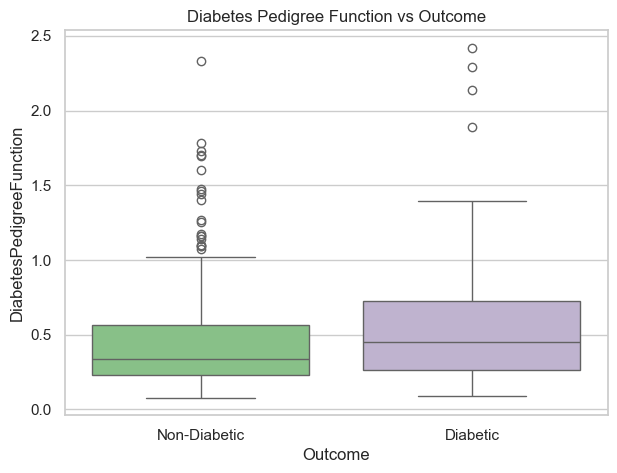

In [61]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Outcome',
    y='DiabetesPedigreeFunction',
    hue='Outcome',legend=False,palette='Accent')
plt.title('Diabetes Pedigree Function vs Outcome')
plt.xticks([0,1],['Non-Diabetic','Diabetic'])

plt.show()

- The diabetic group has a slightly higher median DPF than the non-diabetic group.
- The diabetic group also shows a wider spread, suggesting greater variation in genetic predisposition among diabetic individuals.
- Both groups contain several high-value outliers, but these appear more extreme in the diabetic group.

* **Conclusion:** Individuals with diabetes generally have higher Diabetes Pedigree Function values, indicating that a stronger family history is associated with an increased risk of diabetes, although the overlap suggests it is not a standalone predictor.

## Age vs Non-Diabetic , Diabetic

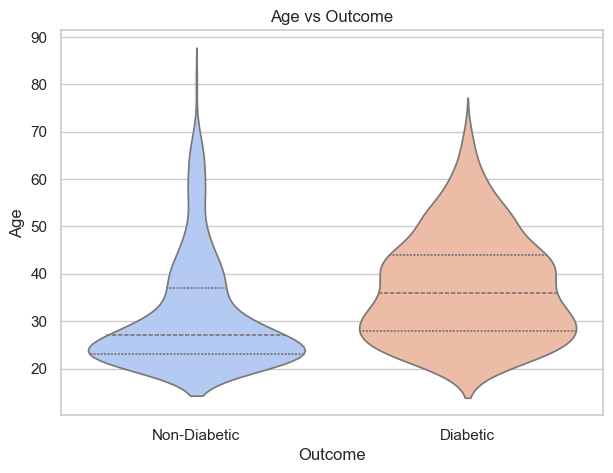

In [63]:
plt.figure(figsize=(7,5))

sns.violinplot(data=df,x='Outcome', y='Age',
    inner='quartile', hue='Outcome',legend=False,palette='coolwarm')

plt.title('Age vs Outcome')
plt.xticks([0,1],['Non-Diabetic','Diabetic'])

plt.show()A

- The diabetic group is shifted toward older ages, with a noticeably higher median age than the non-diabetic group.
- Non-diabetic individuals are more concentrated in the younger age range (around the early to mid-20s), while diabetic individuals are more evenly spread across middle-aged adults.
- Although both groups overlap, the diabetic distribution extends further into older ages, suggesting that diabetes becomes more common as age increases.

* **Conclusion:** Age shows a clear positive relationship with diabetes, with diabetic individuals tending to be older on average than non-diabetic individuals.

## Multivariate Analysis :

###  correlation matrix

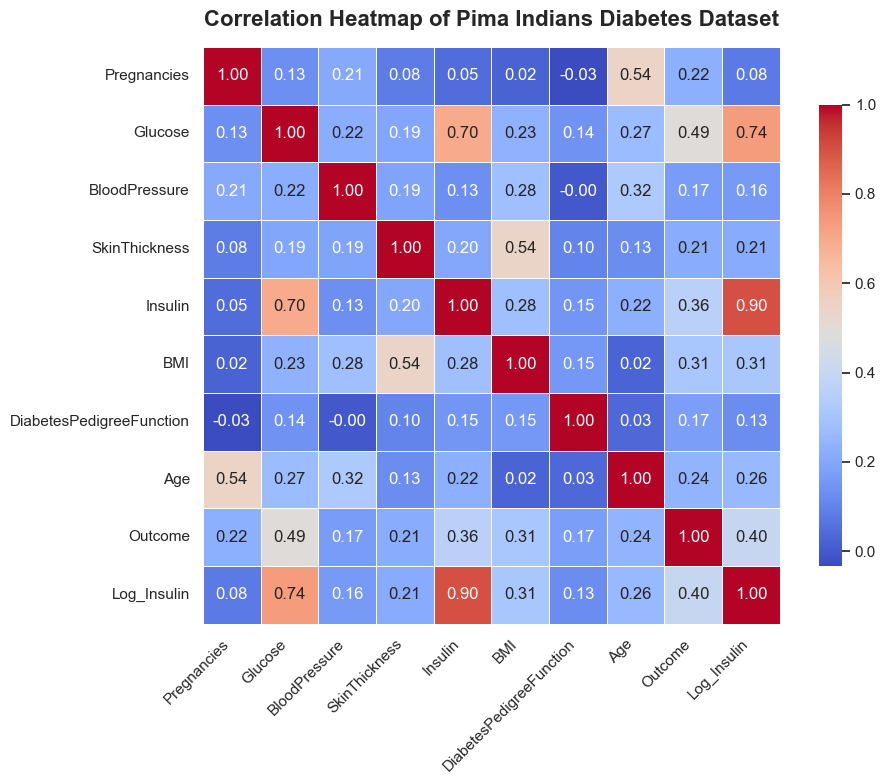

In [90]:
corr_matrix = df.corr(numeric_only=True)

# Create figure
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt=".2f",           # Display 2 decimal places
    cmap="coolwarm",     # Professional color palette
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Pima Indians Diabetes Dataset",
          fontsize=16,
          fontweight='bold',
          pad=15)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Key Findings & Patterns:**
- **Glucose** has the strongest positive correlation with **Outcome** (**r = 0.49**), making it the most influential predictor of diabetes in this dataset.
- **Insulin (0.36)** and **BMI (0.31)** also show moderate positive correlations with the target, suggesting that higher insulin levels and BMI are associated with a greater likelihood of diabetes.
- **Age (0.24)**, **Pregnancies (0.22)**, and **SkinThickness (0.21)** have weak positive correlations with diabetes, indicating they contribute useful information but are weaker predictors individually.
- **BloodPressure (0.17)** and **Diabetes Pedigree Function (0.17)** have only weak positive relationships with the target.
- Among the predictor variables, **Glucose and Insulin (0.70)** show the strongest correlation, followed by **Pregnancies and Age (0.54)** and **SkinThickness and BMI (0.54)**, reflecting meaningful clinical relationships between these measurements.
- No pair of features has an extremely high correlation (greater than 0.8), suggesting that severe multicollinearity is not present in the dataset.

* **Conclusion:** Glucose stands out as the strongest predictor of diabetes, while Insulin and BMI also show meaningful associations. The remaining features provide complementary information, and the absence of strong multicollinearity indicates that all features can be considered for machine learning without major redundancy concerns.

### Risk Segments: Age vs Glucose (Bubble Size = BMI)

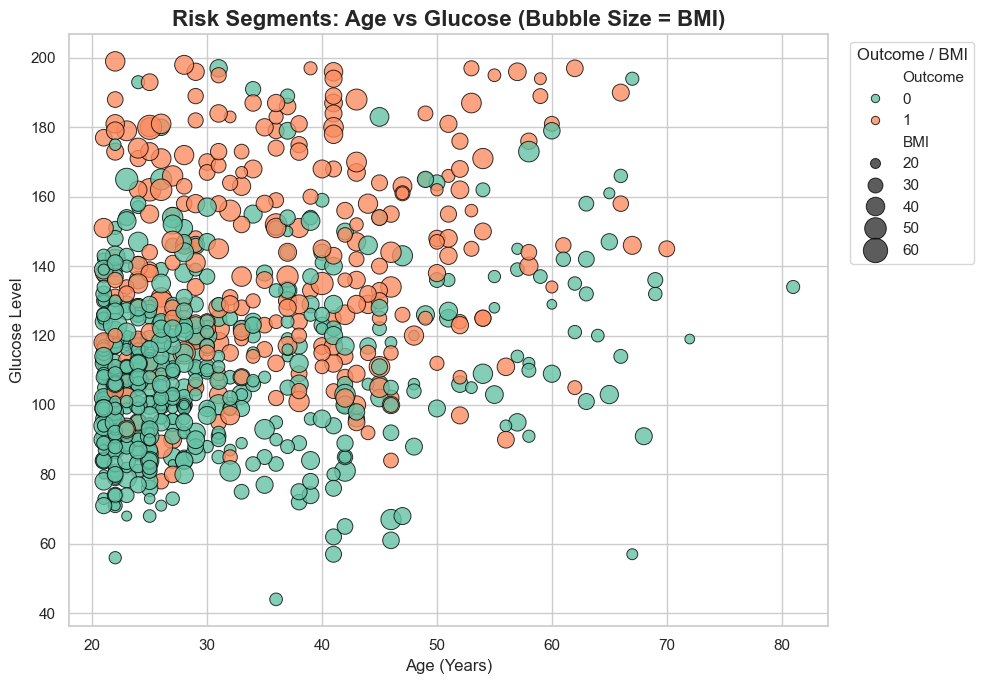

In [84]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Age',
    y='Glucose',
    hue='Outcome',
    size='BMI',
    sizes=(40, 350),
    palette='Set2',
    alpha=0.8,
    edgecolor='black'
)

plt.title('Risk Segments: Age vs Glucose (Bubble Size = BMI)',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Glucose Level', fontsize=12)

plt.legend(title='Outcome / BMI',
           bbox_to_anchor=(1.02,1),
           loc='upper left')

plt.tight_layout()
plt.show()

* **Connecting the Dots:** Earlier, glucose emerged as the strongest individual predictor of diabetes, while age and BMI also showed positive associations with the outcome. This combined view reinforces those findings by showing where these factors come together, making the high-risk regions much easier to spot.

* **What the Interacting Data is Telling Us:**
    - The clearest concentration of diabetic individuals appears in the upper part of the plot, where glucose levels are high. Many of these points also have larger bubble sizes, indicating higher BMI.
    - Non-diabetic individuals are mostly clustered around lower glucose values, especially below roughly 120, even across a wide range of ages. Once glucose increases, diabetic cases become much more common regardless of age.
    - Age alone doesn't create a clear separation, but when higher age is combined with elevated glucose and larger BMI, the diabetic group becomes noticeably more concentrated, forming visible high-risk clusters.

* **The Takeaway:** Glucose remains the strongest driver of diabetes risk, and its effect becomes even more pronounced when paired with higher BMI and increasing age.

## BMI vs Skin Thickness by Diabetes Outcome

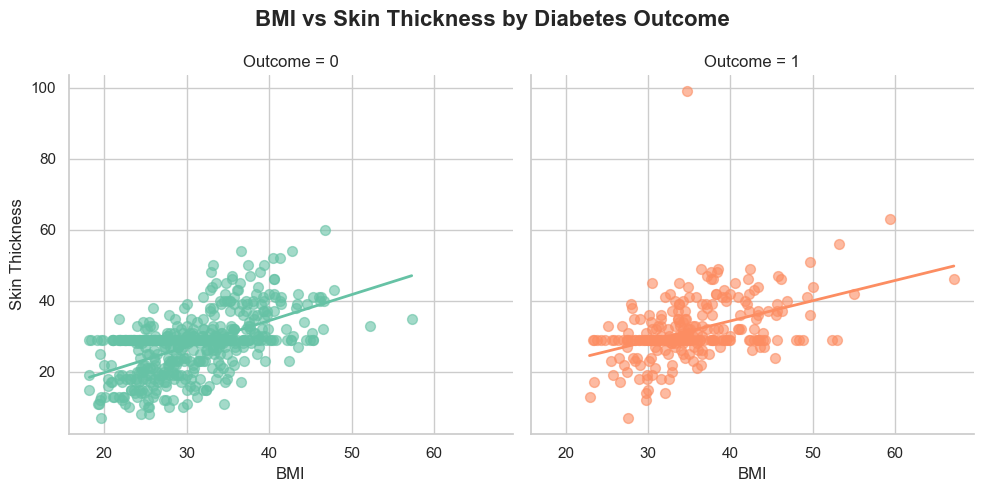

In [86]:
g = sns.lmplot(
    data=df,
    x='BMI',
    y='SkinThickness',
    col='Outcome',
    hue='Outcome',
    palette='Set2',
    height=5,
    aspect=1,
    scatter_kws={'alpha':0.6, 's':50},
    line_kws={'linewidth':2},
    ci=None
)

g.set_titles("Outcome = {col_name}")
g.set_axis_labels("BMI", "Skin Thickness")

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle(
    "BMI vs Skin Thickness by Diabetes Outcome",
    fontsize=16,
    fontweight='bold'
)

plt.show()

* **Connecting the Dots:** Earlier, BMI and Skin Thickness each showed a positive relationship with diabetes, and this plot brings those findings together by showing how they move as a pair. Looking at the two groups separately confirms that the relationship stays positive regardless of diabetes status, while also revealing differences in how the data is distributed.

* **What the Interacting Data is Telling Us:**
    - In both groups, skin thickness tends to increase as BMI increases, which suggests a consistent positive relationship between overall body mass and subcutaneous fat.
    - The diabetic group is more concentrated at higher BMI values and slightly higher skin thickness measurements, indicating that these characteristics often occur together among diabetic individuals.
    - The regression lines have similar upward slopes, so the relationship itself doesn't change much between the two groups; the main difference is that diabetic patients are shifted toward higher values rather than following a completely different pattern.

* **The Takeaway:** BMI and Skin Thickness increase together in both groups, but diabetic individuals are generally clustered at higher values, reinforcing their combined association with diabetes risk.

## Pairwise Relationships of Key Clinical Features

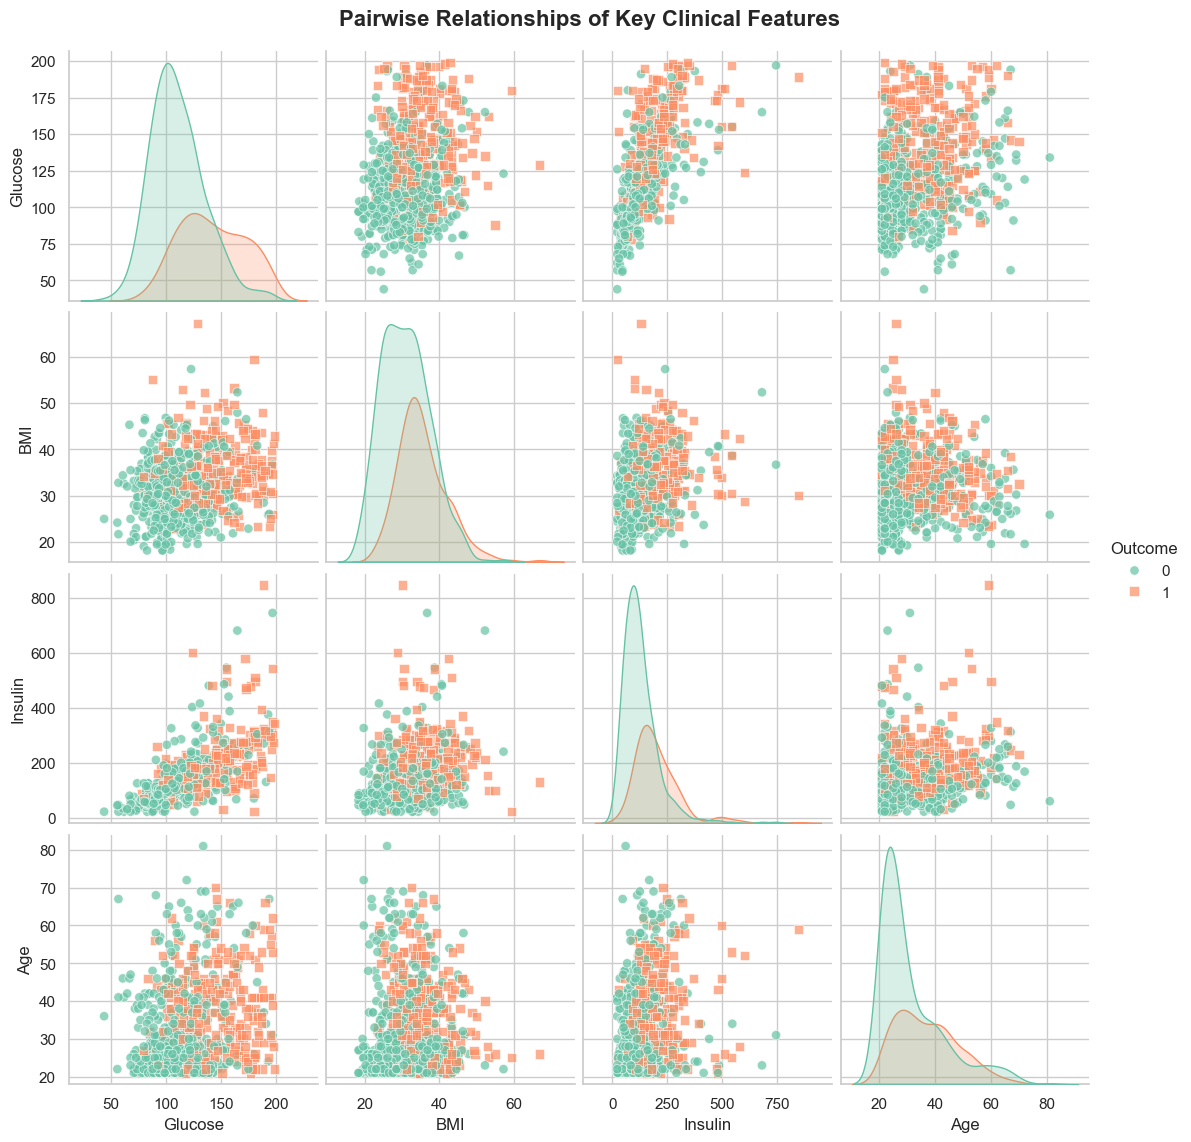

In [87]:
pair_features = [
    'Glucose',
    'BMI',
    'Insulin',
    'Age',
    'Outcome']

g = sns.pairplot(
    df[pair_features],
    hue='Outcome',
    palette='Set2',
    diag_kind='kde',
    diag_kws={'fill':True},
    markers=['o','s'],
    plot_kws={
        'alpha':0.7,
        's':45
    },
    height=2.8
)

g.fig.suptitle(
    "Pairwise Relationships of Key Clinical Features",
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.show()

* **Connecting the Dots:** The pairplot brings together the strongest predictors we identified earlier—Glucose, BMI, Insulin, and Age—and shows how they interact instead of looking at them one at a time. It confirms that no single feature perfectly separates the two groups, but combining these variables makes the diabetic and non-diabetic patterns much more distinct.

* **What the Interacting Data is Telling Us:**
    - Glucose provides the clearest separation, with diabetic individuals concentrated at higher glucose levels across almost every feature combination.
    - BMI, Insulin, and Age strengthen this pattern. Diabetic patients are more frequently found where these variables are simultaneously higher, forming noticeable high-risk clusters rather than isolated points.
    - The diagonal density plots show considerable overlap between the two classes, explaining why diabetes cannot be predicted reliably from any single measurement alone. The scatter plots reveal that combining multiple clinical features improves the distinction between diabetic and non-diabetic individuals.

* **The Takeaway:** Diabetes is driven by the combined effect of multiple clinical factors, and Glucose, BMI, Insulin, and Age together provide a much clearer picture of diabetes risk than any individual feature on its own.

# Final EDA Report & Analytical Conclusion

## Executive Summary

This analysis reveals that diabetes is influenced by the combined effect of several physiological factors rather than any single measurement. Across the dataset, individuals with diabetes consistently showed higher glucose levels, higher BMI, higher insulin levels, and were generally older than non-diabetic individuals. While many features individually showed considerable overlap between the two groups, combining them through multivariate analysis produced much clearer separation and highlighted distinct high-risk patient clusters. Overall, glucose emerged as the strongest clinical indicator, with BMI, insulin, age, and family history acting as complementary risk factors.

---

## Hypothesis Validation Checklist

| Initial Hypothesis | Status | The Visual Evidence (What the graphs proved) |
|:-------------------|:------:|:---------------------------------------------|
| High Glucose is the primary indicator of diabetic outcomes. | ✅ **Validated** | KDE plots, correlation heatmap, scatter plots, and pairplot consistently showed glucose as the strongest feature separating diabetic and non-diabetic individuals (highest correlation with Outcome: **0.49**). |
| High BMI and SkinThickness scale linearly and create a high-risk cluster. | ✅ **Validated** | Faceted regression plots showed a clear positive relationship between BMI and SkinThickness in both groups, with diabetic individuals clustering at generally higher values. |
| The presence of "0" values in structural metrics (Insulin, SkinThickness, BMI) represents missing data rather than biological reality. | ✅ **Validated** | Domain knowledge confirms that living adults cannot have zero values for these measurements. Replacing zeros as missing values produced more realistic feature distributions and improved interpretability. |
| Age and Pregnancies create a compound risk factor over time. | 🟡 **Nuanced** | Both features showed positive associations with diabetes, and multivariate plots indicated higher diabetes prevalence among older individuals with more pregnancies. However, neither feature alone clearly separated the two outcome classes. |

---

## Critical Key Findings

- **Glucose consistently stood out as the strongest predictor of diabetes**, showing the clearest separation between diabetic and non-diabetic individuals across every stage of the analysis.
- **No single feature perfectly distinguished the two classes.** The clearest separation appeared only after combining Glucose, BMI, Insulin, and Age, highlighting the multifactorial nature of diabetes.
- **Insulin exhibited extreme right-skewness and several outliers.** Applying a log transformation produced a much more interpretable distribution while preserving the underlying relationship with diabetes.
- **BMI, SkinThickness, and Age reinforced one another rather than acting independently.** Patients with diabetes tended to occupy regions where several risk factors were simultaneously elevated, forming recognizable high-risk clusters in multivariate visualizations.

---

##  Conclusion

The exploratory analysis confirms that diabetes in the Pima Indians dataset is driven by the interaction of multiple physiological characteristics rather than a single clinical measurement. Glucose remains the dominant predictor, while BMI, insulin, age, and family history provide complementary information that strengthens the overall prediction of diabetes risk.

---

## 5. Data-Driven Action Items for Modeling

1. **Handle biologically impossible zero values before model training** by treating zeros in **Glucose, BloodPressure, SkinThickness, Insulin, and BMI** as missing values and imputing them using clinically appropriate methods (e.g., median imputation or KNN imputation).

2. **Prioritize the strongest predictive features**—particularly **Glucose, BMI, Insulin, Age, and Diabetes Pedigree Function**—as these consistently demonstrated the strongest separation between diabetic and non-diabetic individuals throughout the analysis.

3. **Engineer interaction and transformed features** to better capture nonlinear relationships, such as:
   - BMI × Glucose
   - Age × Pregnancies
   - Log-transformed Insulin
   - BMI categories (Normal, Overweight, Obese)
   - Age groups

4. **Address the moderate class imbalance** in the Outcome variable (approximately **65% non-diabetic vs. 35% diabetic**) by using **stratified train-test splitting**, evaluating models with **Precision, Recall, F1-score, and ROC-AUC**, and considering resampling techniques such as **SMOTE** if minority-class performance is insufficient.